<a href="https://colab.research.google.com/github/adiban17/Deep-Learning-Models/blob/main/Next_Word_Prediction(RNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RNN for Next Word Prediction**

**Objective :** To understand how a RNN can be used to predict the next word in a sentence based on previous words.

Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt


In [2]:
# Load Dataset
path = tf.keras.utils.get_file("shakespeare.txt","https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt")
text = open(path).read().lower()[:200000]

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
text

"first citizen:\nbefore we proceed any further, hear me speak.\n\nall:\nspeak, speak.\n\nfirst citizen:\nyou are all resolved rather to die than to famish?\n\nall:\nresolved. resolved.\n\nfirst citizen:\nfirst, you know caius marcius is chief enemy to the people.\n\nall:\nwe know't, we know't.\n\nfirst citizen:\nlet us kill him, and we'll have corn at our own price.\nis't a verdict?\n\nall:\nno more talking on't; let it be done: away, away!\n\nsecond citizen:\none word, good citizens.\n\nfirst citizen:\nwe are accounted poor citizens, the patricians good.\nwhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to them let us revenge this with\nour pikes, ere we become rakes: for the gods know i\nspeak this in hunger 

Tokenization

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
total_words

4900

Create Sequences

In [5]:
# Create Input Sequences
input_sequences = []
for line in text.split('\n'):
  token_list = tokenizer.texts_to_sequences([line])[0]
  for i in range(1, len(token_list)):
    input_sequences.append(token_list[:i+1])

In [6]:
token_list

[4899]

In [7]:
input_sequences

[[39, 82],
 [113, 25],
 [113, 25, 557],
 [113, 25, 557, 193],
 [113, 25, 557, 193, 275],
 [113, 25, 557, 193, 275, 99],
 [113, 25, 557, 193, 275, 99, 23],
 [113, 25, 557, 193, 275, 99, 23, 100],
 [100, 100],
 [39, 82],
 [4, 28],
 [4, 28, 32],
 [4, 28, 32, 717],
 [4, 28, 32, 717, 196],
 [4, 28, 32, 717, 196, 3],
 [4, 28, 32, 717, 196, 3, 276],
 [4, 28, 32, 717, 196, 3, 276, 47],
 [4, 28, 32, 717, 196, 3, 276, 47, 3],
 [4, 28, 32, 717, 196, 3, 276, 47, 3, 1406],
 [717, 717],
 [39, 82],
 [39, 4],
 [39, 4, 94],
 [39, 4, 94, 277],
 [39, 4, 94, 277, 48],
 [39, 4, 94, 277, 48, 20],
 [39, 4, 94, 277, 48, 20, 1407],
 [39, 4, 94, 277, 48, 20, 1407, 298],
 [39, 4, 94, 277, 48, 20, 1407, 298, 3],
 [39, 4, 94, 277, 48, 20, 1407, 298, 3, 1],
 [39, 4, 94, 277, 48, 20, 1407, 298, 3, 1, 87],
 [25, 1054],
 [25, 1054, 25],
 [25, 1054, 25, 1054],
 [39, 82],
 [73, 55],
 [73, 55, 299],
 [73, 55, 299, 19],
 [73, 55, 299, 19, 2],
 [73, 55, 299, 19, 2, 313],
 [73, 55, 299, 19, 2, 313, 14],
 [73, 55, 299, 19, 2

Padding and Labels

In [8]:
# Padding
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
print('Total number of input sequences:', len(input_sequences))
print('\nMaximum Length of the Input Sequence:', max_len)
input_sequences

Total number of input sequences: 29966

Maximum Length of the Input Sequence: 13


array([[   0,    0,    0, ...,    0,   39,   82],
       [   0,    0,    0, ...,    0,  113,   25],
       [   0,    0,    0, ...,  113,   25,  557],
       ...,
       [   0,    0,    0, ...,   17,    9,   31],
       [   0,    0,    0, ...,    9,   31,  362],
       [   0,    0,    0, ...,   31,  362, 1369]], dtype=int32)

In [9]:
X = input_sequences[:,:-1]
y = tf.keras.utils.to_categorical(input_sequences[:,-1], num_classes=total_words)

print(f"Total Sequences: {len(input_sequences)}, Vocabulary size: {total_words}")
X.shape, y.shape

Total Sequences: 29966, Vocabulary size: 4900


((29966, 12), (29966, 4900))

Build and Train RNN Model

In [10]:
# Build Model
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_len-1))
model.add(SimpleRNN(128))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train Model
history = model.fit(X, y, epochs=50, batch_size=128, validation_split=0.1)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 27s 98ms/step - accuracy: 0.0358 - loss: 6.9269 - val_accuracy: 0.0370 - val_loss: 6.9612
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.0457 - loss: 6.4514 - val_accuracy: 0.0424 - val_loss: 6.9398
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.0538 - loss: 6.2246 - val_accuracy: 0.0531 - val_loss: 6.8941
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 101ms/step - accuracy: 0.0715 - loss: 5.9661 - val_accuracy: 0.0597 - val_loss: 6.8880
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.0854 - loss: 5.7159 - val_accuracy: 0.0701 - val_loss: 6.9206
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.0962 - loss: 5.4839 - val_accuracy: 0.0687 - val_loss: 6.8929
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.1081 - loss: 5.2584 - val_accuracy: 0.0667 - val_loss: 6.9834
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - accuracy: 0.1174 - loss: 5.0432 -

Training Loss & Accuracy Plot

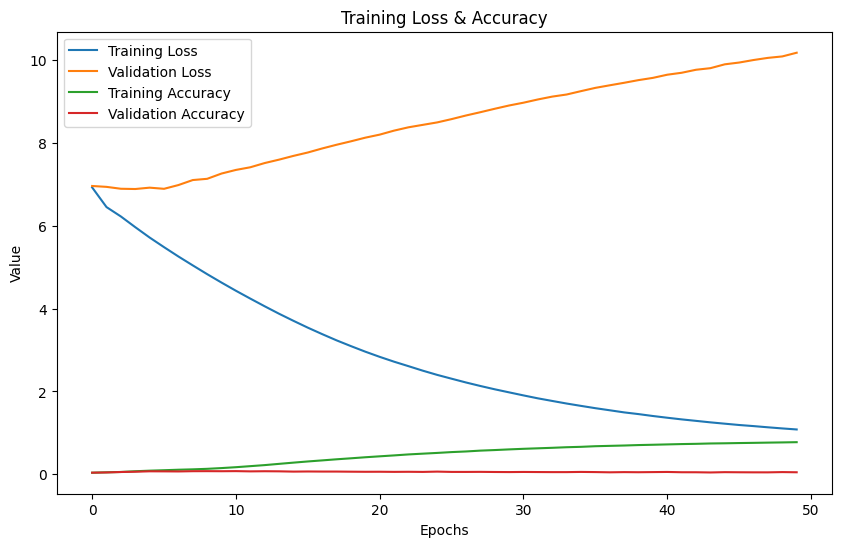

In [12]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training Loss & Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

Word Embedding PCA Visualization

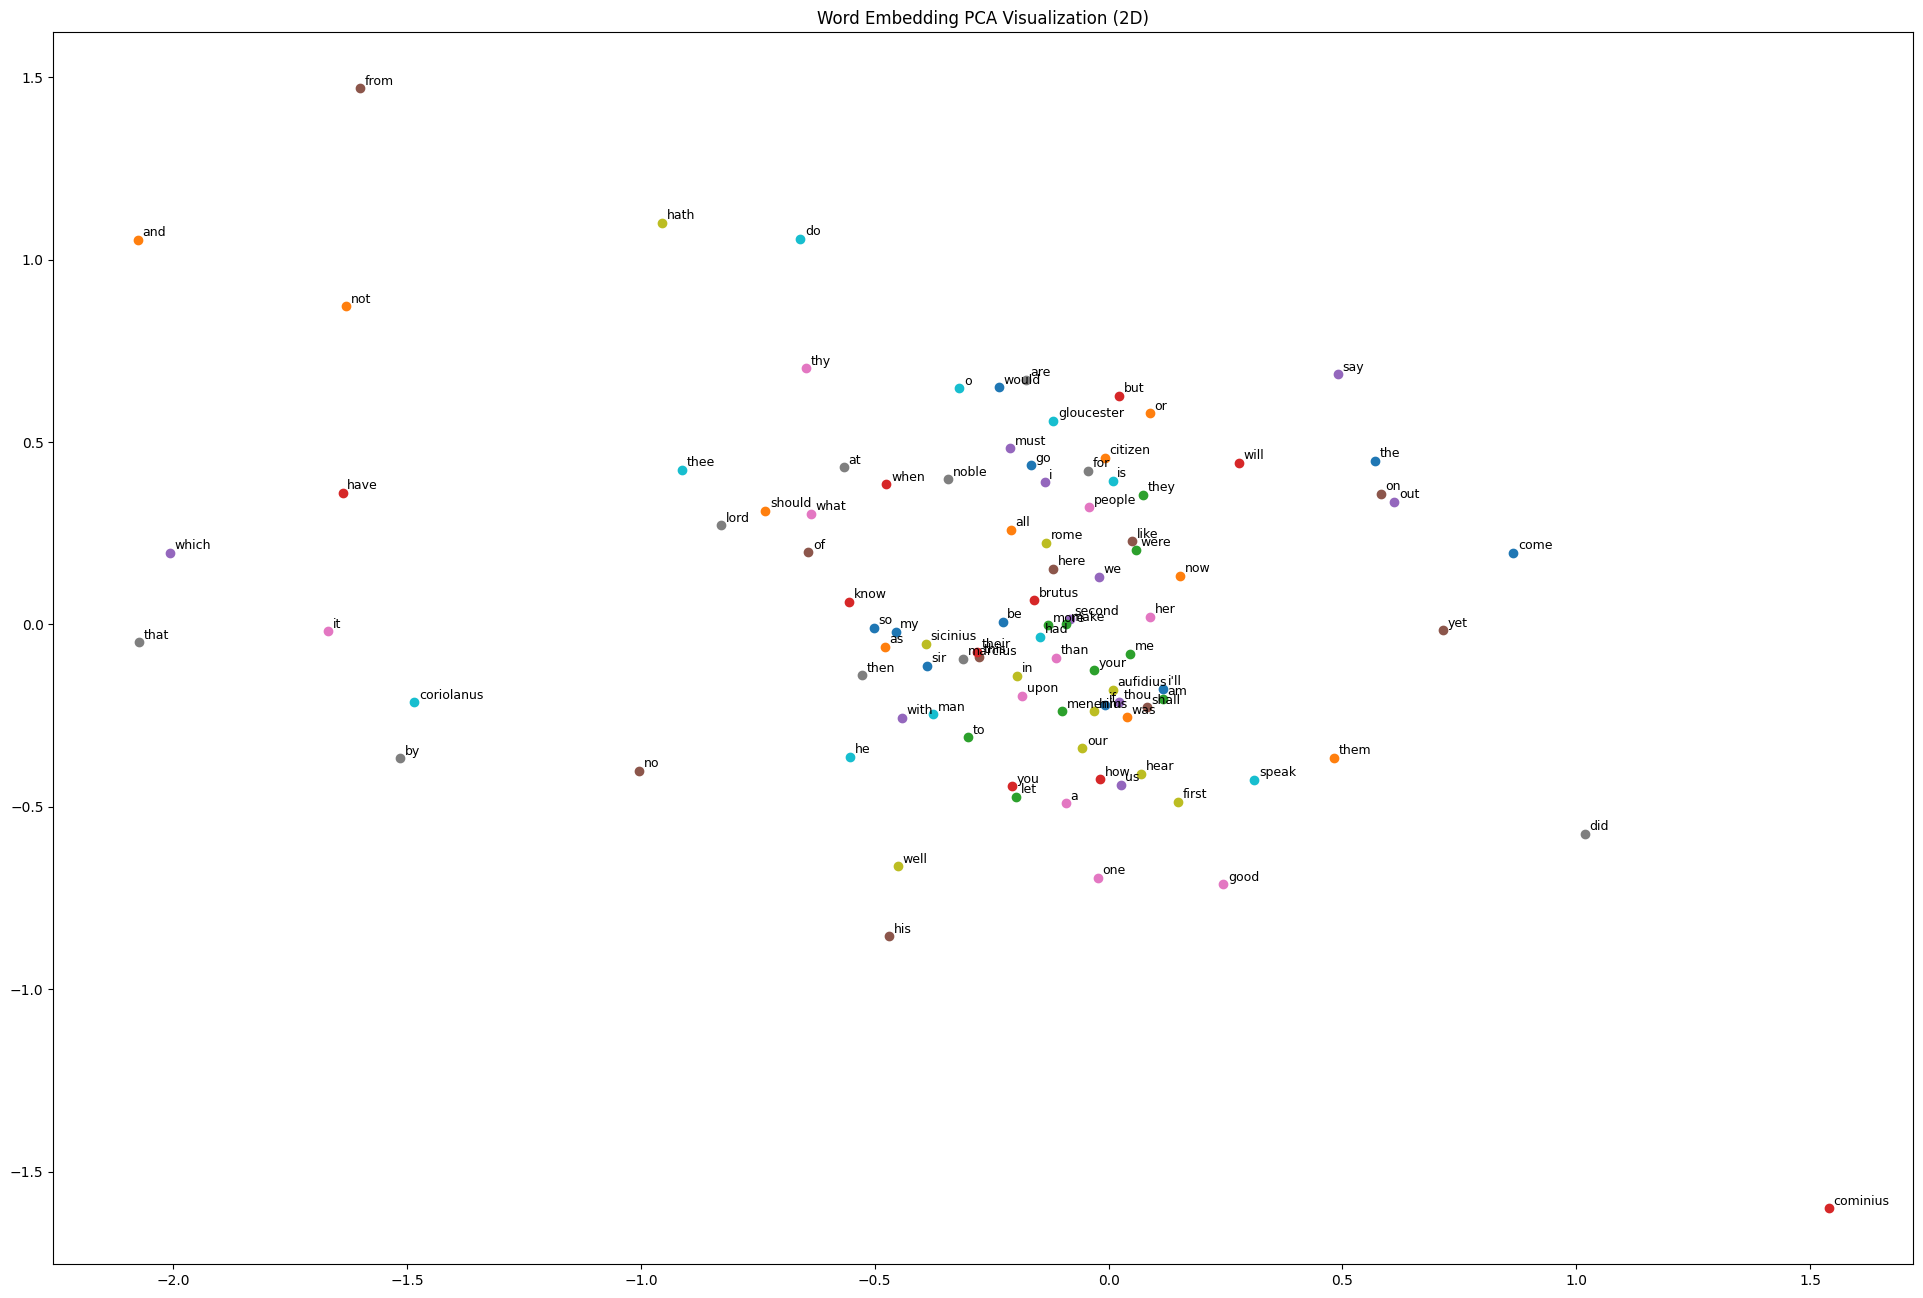

In [15]:
from sklearn.decomposition import PCA

# Extract embeddings
embeddings = model.layers[0].get_weights()[0]    # Embedding layer weights

# Reduce Dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Plot the first 100 words
plt.figure(figsize=(24, 16))
for i, word in enumerate(list(tokenizer.word_index.keys())[:100]):
  xnew, ynew = embeddings_2d[i]
  plt.scatter(xnew, ynew)
  plt.text(xnew+0.01, ynew+0.01, word, fontsize=9)
plt.title('Word Embedding PCA Visualization (2D)')
plt.show()

Next-Word Prediction Function

In [18]:
def predict_next_word(seed_text, n_words=5):
  result = seed_text

  for _ in range(n_words):
    seq = tokenizer.texts_to_sequences([result])[0]
    seq = pad_sequences([seq], maxlen=max_len-1, padding='pre')
    pred_probs = model.predict(seq, verbose=0)[0]
    pred_index = np.argmax(pred_probs)

    # Map index back to word
    for word, index in tokenizer.word_index.items():
      if index == pred_index:
        result += " " + word
        break
  return result

Test Prediction

In [19]:
# Example
seed = 'this is a noble of the'
print(predict_next_word(seed, 5))

this is a noble of the patricians that they not know


Next-Word Prediction Probability Bar Chart

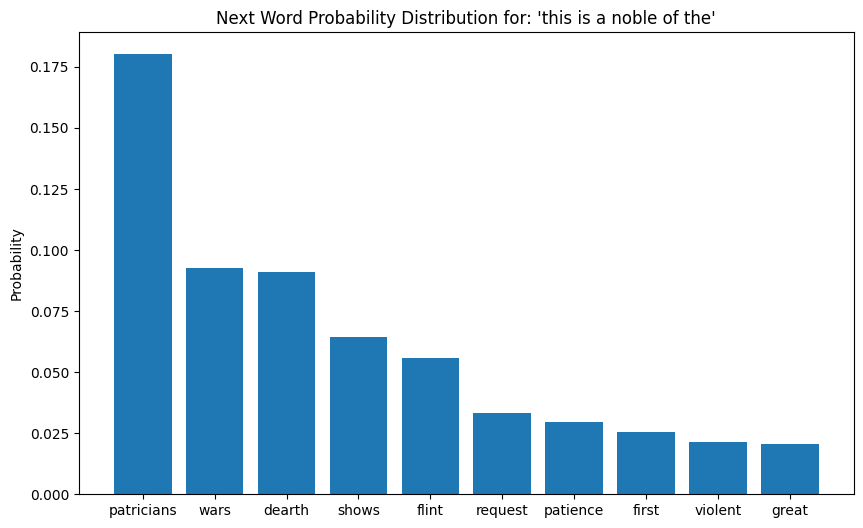

In [20]:
seed_text = 'this is a noble of the'
seq = tokenizer.texts_to_sequences([seed_text])[0]
seq = pad_sequences([seq], maxlen=max_len-1, padding='pre')
pred_probs = model.predict(seq, verbose=0)[0]

# Top 10 predicted words
top_indices = pred_probs.argsort()[-10:][::-1]
top_words = [tokenizer.index_word[i] for i in top_indices]
top_probs = [pred_probs[i] for i in top_indices]

plt.figure(figsize=(10, 6))
plt.bar(top_words, top_probs)
plt.title(f"Next Word Probability Distribution for: '{seed_text}'")
plt.ylabel('Probability')
plt.show()